In [1]:
library(Seurat)
library(ggplot2)
library(e1071)
library(purrr)
library(dplyr)
library(preprocessCore)
library(pROC)
library(CMAP)
library(reticulate)
library(scatterpie)
library(cowplot)
#use_condaenv('/home/kejincan/.conda/envs/vers_2/bin/python')


load("/home/kejincan/Project/SingleCellMapping/Data/2022_CARD_Simulated_MOB/Data/20221023.CARD_Simulate_Data.Paired_Cell_Resource.sc_count.sc_meta.spatial_count.spatial_location.Rdata")
load("/home/kejincan/Project/SingleCellMapping/Data/2022_CARD_Simulated_MOB/Data/20221024.Simulate_data_Cell_resource.binSpect.filterSpatialGenes.my_spatial_genes.spatial_location.Rdata")
sc_meta <- sc_meta[sc_meta$cellType!='Ependymal',] 
sc_count <- sc_count[,rownames(sc_meta)]
all(rownames(sc_count)==rownames(spatial_count))
spatial_count <- spatial_count[rowSums(spatial_count)>0,]
sc_count <- sc_count[rowSums(sc_count)>0,]

all(colnames(spatial_count)==rownames(spatial_location))
spatial_location$HMRF_cluster <- paste0('cluster_',spatial_location$HMRF_k3_b.40)
spatial_location$true_label <- paste0('cluster_',spatial_location$pattern_gp_label)

spatial_location[spatial_location$pattern_gp_label == '2','true_label'] = 'cluster_3'
spatial_location[spatial_location$pattern_gp_label == '3','true_label'] = 'cluster_2'
table(spatial_location$true_label)

all(colnames(sc_count)==rownames(sc_meta))
sc_meta$spot_cluster <- spatial_location[sc_meta$spot,'HMRF_cluster']
sc_meta$true_label <- spatial_location[sc_meta$spot,'true_label']

sc_norm = log1p(sweep(sc_count,2,Matrix::colSums(sc_count),FUN = '/') * 1e4)
st_norm = log1p(sweep(spatial_count,2,Matrix::colSums(spatial_count),FUN = '/') * 1e4)

Attaching SeuratObject


载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Type 'citation("pROC")' for a citation.


载入程辑包：‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




[1] TRUE

[1] TRUE


cluster_1 cluster_2 cluster_3 
      140        75        45 

[1] TRUE

In [2]:
all(rownames(sc_meta)==colnames(sc_norm))

[1] TRUE

In [3]:
sc_meta$cellType <- as.character(sc_meta$cellType)

In [4]:
st_norm <- st_norm[rowSums(st_norm)>0,]
sc_norm <- sc_norm[rowSums(sc_norm)>0,]
dim(st_norm)
dim(sc_norm)

[1] 17073   260

[1] 16975  2242

In [5]:
matrix <- data_to_transform(sc_norm,st_norm,my_spatial_genes,batch=TRUE,pca_method='prcomp_irlba')
train_set <- cbind(as.data.frame(t(matrix[,colnames(st_norm)])),label=spatial_location$HMRF_cluster)
test_set <- as.data.frame(t(matrix[,colnames(sc_norm)]))
train_set$label = as.factor(train_set$label)
# Step1: predict spatial domain of individual cells
pred_st_svm <- PredictDomain(train_set, test_set, cost = 2,gamma = 0.03125, st_svm=TRUE,verbose = FALSE)
table(pred_st_svm)
pred_sc_svm <- PredictDomain(train_set, test_set, cost = 2,gamma = 0.03125, scale = TRUE, verbose = TRUE)
sum(diag(table(pred_sc_svm,pred_st_svm[sc_meta$spot])))
sum(diag(table(pred_sc_svm,pred_st_svm[sc_meta$spot])))/dim(sc_meta)[1]
table(pred_sc_svm,pred_st_svm[sc_meta$spot]) 

pred_st_svm
cluster_1 cluster_2 cluster_3 
      141        74        45 

[1] "The prediction table of training data"
pred_st_svm
cluster_1 cluster_2 cluster_3 
      141        74        45 
[1] "The accuracy of spatial data:0.988461538461539"
[1] "The prediction table of test data"
pred_sc_svm
cluster_1 cluster_2 cluster_3 
     1002       871       369 


[1] 1678

[1] 0.7484389

           
pred_sc_svm cluster_1 cluster_2 cluster_3
  cluster_1       887        48        67
  cluster_2       308       502        61
  cluster_3        66        14       289

In [6]:
table(apply(attr(pred_sc_svm, "probabilities"),1,max)>0.5)
min(apply(attr(pred_sc_svm, "probabilities"),1,max))


FALSE  TRUE 
   27  2215 

[1] 0.3798436

In [7]:
all(rownames(sc_meta)==names(pred_sc_svm))

[1] TRUE

In [8]:
sc_meta <- sc_meta[apply(attr(pred_sc_svm, "probabilities"),1,max)>0.5,]
dim(sc_meta)
pred_sc_svm <- pred_sc_svm[apply(attr(pred_sc_svm, "probabilities"),1,max)>0.5]

sum(diag(table(pred_sc_svm,pred_st_svm[sc_meta$spot])))
sum(diag(table(pred_sc_svm,pred_st_svm[sc_meta$spot])))/dim(sc_meta)[1]
table(pred_sc_svm,pred_st_svm[sc_meta$spot]) 

[1] 2215    6

[1] 1668

[1] 0.7530474

           
pred_sc_svm cluster_1 cluster_2 cluster_3
  cluster_1       886        37        66
  cluster_2       304       493        61
  cluster_3        65        14       289

In [18]:
# Step2: map cell to individual spot
python_path <- '/home/kejincan/.conda/envs/vers_2copy/bin/python'
cell_spot_map <- map_cell_to_spot(sc_norm=sc_norm,sc_meta=sc_meta,
                                  st_norm=st_norm,spatial_location=spatial_location,
                                  pred_sc_svm=pred_sc_svm, pred_st_svm=pred_st_svm,
                                  python_path=python_path,
                                  batch=TRUE,
                                  pca_method = "prcomp",
                                  num_epochs=2000L,
                                  para_distance=1.0,
                                  para_density=1.0)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 56500)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 46600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 46600)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 46600)”
Warning message:
“Quick-TRANSfer stage steps exceed

In [19]:
sum(cell_spot_map$Spot==sc_meta[as.character(cell_spot_map$Single_cell),'spot'])
sum(cell_spot_map$Spot==sc_meta[as.character(cell_spot_map$Single_cell),'spot'])/dim(cell_spot_map)[1]
sum(cell_spot_map$Spot==sc_meta[as.character(cell_spot_map$Single_cell),'spot'])/2242

[1] 1629

[1] 0.7354402

[1] 0.7265834

In [20]:
(sum(cell_spot_map$Spot==sc_meta[as.character(cell_spot_map$Single_cell),'spot'])/dim(sc_meta)[1]) * (dim(cell_spot_map)[1]/2242)

[1] 0.7265834

In [21]:
# Step3: give cell an exact position
spatial_location_tmp <- spatial_location
spatial_location_tmp$x <- spatial_location_tmp$x_round
spatial_location_tmp$y <- spatial_location_tmp$y_round
spot_neigh_list <- spatial_relation_all(spatial_location_tmp,
                                        spatial_data_type=c('square'),n_near_spot=5,dis_cut=1.2)

In [22]:
sc_meta_coord <- calculate_cell_location(cell_spot_map=cell_spot_map,
                                         st_meta =spatial_location,
                                         sc_meta=sc_meta,
                                         sc_norm=sc_norm,
                                         st_norm=st_norm,
                                         batch = TRUE,
                                         spot_neigh_list=spot_neigh_list,
                                         radius = 1/6)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 125100)”


In [23]:
save(cell_spot_map,sc_meta_coord,file="../../Result/20240724.Simulated_MOB.CAMPv4.Filter.0.5/20240724.Simulated_MOB.CMAPv4.Filter_0.5.73per.Rdata")

In [5]:
load("../../Result/20240724.Simulated_MOB.CAMPv4.Filter.0.5/20240724.Simulated_MOB.CMAPv4.Filter_0.5.73per.Rdata")
dim(cell_spot_map)
head(sc_meta_coord)
head(cell_spot_map)

[1] 2215    3

,id_raw,cell_id_new,spot,cellType,spot_cluster,true_label,pred_loc_x,pred_loc_y
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
X10X49_4_ATACCTGGACAG.,10X49_4_ATACCTGGACAG-,X10X49_4_ATACCTGGACAG.,16.92x9.015,Neurons,cluster_1,cluster_1,16.81339,9.020334
X10X28_5_AAATTCGAAGATGA.1,10X28_5_AAATTCGAAGATGA-1,X10X28_5_AAATTCGAAGATGA.1,16.92x9.015,Neurons,cluster_1,cluster_1,16.91678,9.205425
X10X28_5_GAACTGTGGACGAG.1,10X28_5_GAACTGTGGACGAG-1,X10X28_5_GAACTGTGGACGAG.1,16.92x9.015,Neurons,cluster_1,cluster_1,16.91374,9.076238
X10X49_4_CTAGCTGCGGAA.,10X49_4_CTAGCTGCGGAA-,X10X49_4_CTAGCTGCGGAA.,16.92x9.015,Neurons,cluster_1,cluster_1,16.91297,9.259044
X10X49_4_AACTCTTGGTCA.,10X49_4_AACTCTTGGTCA-,X10X49_4_AACTCTTGGTCA.,16.92x9.015,Neurons,cluster_1,cluster_1,16.78364,9.019460
X10X49_5_AATCGAATTGGC.,10X49_5_AATCGAATTGGC-,X10X49_5_AATCGAATTGGC.,16.92x9.015,Immune,cluster_1,cluster_1,16.90803,9.172598


,Single_cell,Spot,Probability
,<chr>,<chr>,<dbl>
1,X10X49_4_ATACCTGGACAG.,16.92x9.015,0.08123193
2,X10X28_5_AAATTCGAAGATGA.1,16.92x9.015,0.08424974
3,X10X28_5_GAACTGTGGACGAG.1,16.92x9.015,0.10700449
4,X10X49_4_CTAGCTGCGGAA.,16.92x9.015,0.07027335
5,X10X49_4_AACTCTTGGTCA.,16.92x9.015,0.09940101
6,X10X49_5_AATCGAATTGGC.,16.92x9.015,0.13622782


In [6]:
head(sc_meta)

,id_raw,cell_id_new,spot,cellType,spot_cluster,true_label
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
X10X49_4_ATACCTGGACAG.,10X49_4_ATACCTGGACAG-,X10X49_4_ATACCTGGACAG.,16.92x9.015,Neurons,cluster_1,cluster_1
X10X28_5_AAATTCGAAGATGA.1,10X28_5_AAATTCGAAGATGA-1,X10X28_5_AAATTCGAAGATGA.1,16.92x9.015,Neurons,cluster_1,cluster_1
X10X28_5_GAACTGTGGACGAG.1,10X28_5_GAACTGTGGACGAG-1,X10X28_5_GAACTGTGGACGAG.1,16.92x9.015,Neurons,cluster_1,cluster_1
X10X49_4_CTAGCTGCGGAA.,10X49_4_CTAGCTGCGGAA-,X10X49_4_CTAGCTGCGGAA.,16.92x9.015,Neurons,cluster_1,cluster_1
X10X49_4_AACTCTTGGTCA.,10X49_4_AACTCTTGGTCA-,X10X49_4_AACTCTTGGTCA.,16.92x9.015,Neurons,cluster_1,cluster_1
X10X49_4_GTACACGAAGGC.,10X49_4_GTACACGAAGGC-,X10X49_4_GTACACGAAGGC.,16.92x9.015,Oligos,cluster_1,cluster_1


In [7]:
all(as.character(cell_spot_map$Single_cell) %in% rownames(sc_meta))
all(rownames(sc_meta) %in% as.character(cell_spot_map$Single_cell))
sum(as.character(cell_spot_map$Spot)==sc_meta[as.character(cell_spot_map$Single_cell),'spot'])

[1] TRUE

[1] FALSE

[1] 1629

In [8]:
sum(as.character(cell_spot_map$Spot)==sc_meta[as.character(cell_spot_map$Single_cell),'spot'])/dim(sc_meta)[1]
(1629/dim(sc_meta)[1]) * (dim(sc_meta)[1]/2242)

[1] 0.7265834

[1] 0.7265834

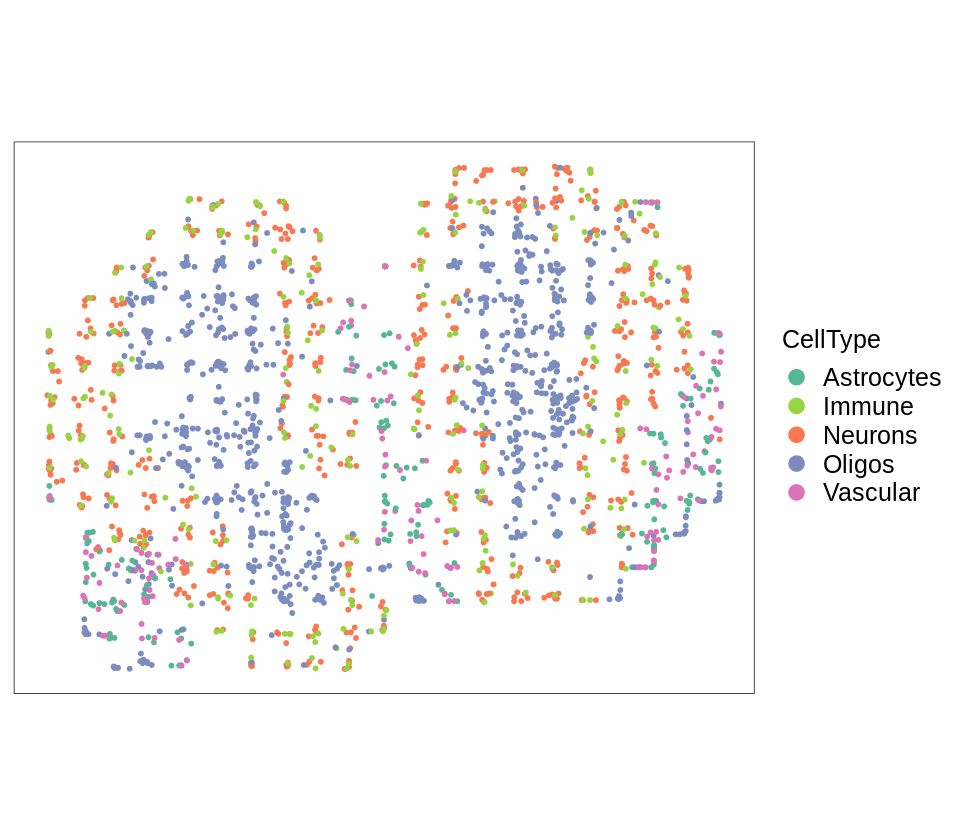

In [9]:
options(repr.plot.width = 8, repr.plot.height = 7)
ggplot(sc_meta_coord,aes(pred_loc_x,pred_loc_y,color=cellType))+
    geom_point(size=1)+ #点的大小
   scale_color_manual(values = c(
                             "Astrocytes" = "#56B794",
                             "Ependymal" = "#FED225",
                             "Immune" = "#97D442",
                             "Neurons" = "#F87850",
                             "Oligos" = "#7B8CBF",
                             "Vascular" = "#DE72B6"))+
    theme_bw() +#去除背景
    theme(panel.grid.major=element_line(colour=NA), 
          panel.background = element_rect(fill = "transparent",colour = NA),
          plot.background = element_rect(fill = "transparent",colour = NA),
          ,panel.grid.minor=element_blank(),
          axis.text = element_blank(),
          axis.ticks = element_blank())+ coord_fixed()+
    labs(x=NULL,y=NULL,color= 'Cell Type')+
    theme(plot.title = element_text(hjust = 0.5)) + # 居中
   theme(legend.position='right',
        legend.text=element_text(size=15),
        legend.title=element_text(size=15))+
    guides(color = guide_legend(title="CellType",override.aes = list(size = 4)))

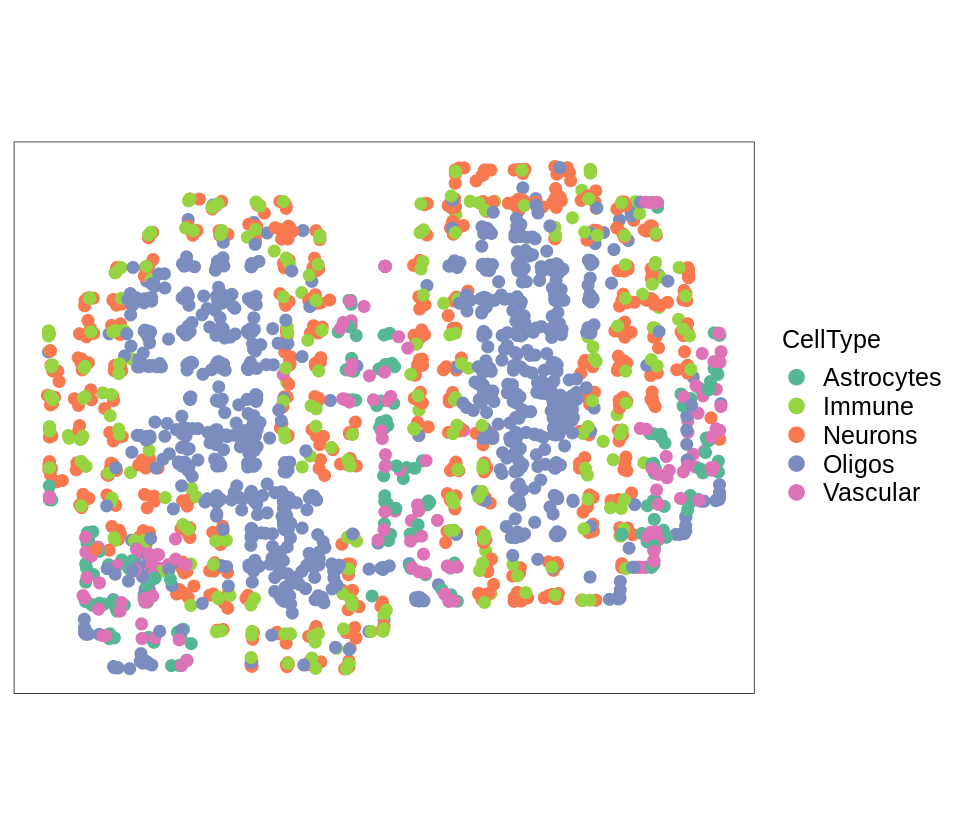

In [10]:
options(repr.plot.width = 8, repr.plot.height = 7)
ggplot(sc_meta_coord,aes(pred_loc_x,pred_loc_y,color=cellType))+
    geom_point(size=3)+ #点的大小
   scale_color_manual(values = c(
                             "Astrocytes" = "#56B794",
                             "Ependymal" = "#FED225",
                             "Immune" = "#97D442",
                             "Neurons" = "#F87850",
                             "Oligos" = "#7B8CBF",
                             "Vascular" = "#DE72B6"))+
    theme_bw() +#去除背景
    theme(panel.grid.major=element_line(colour=NA), 
          panel.background = element_rect(fill = "transparent",colour = NA),
          plot.background = element_rect(fill = "transparent",colour = NA),
          ,panel.grid.minor=element_blank(),
          axis.text = element_blank(),
          axis.ticks = element_blank())+ coord_fixed()+
    labs(x=NULL,y=NULL,color= 'Cell Type')+
    theme(plot.title = element_text(hjust = 0.5)) + # 居中
   theme(legend.position='right',
        legend.text=element_text(size=15),
        legend.title=element_text(size=15))+
    guides(color = guide_legend(title="CellType",override.aes = list(size = 4)))

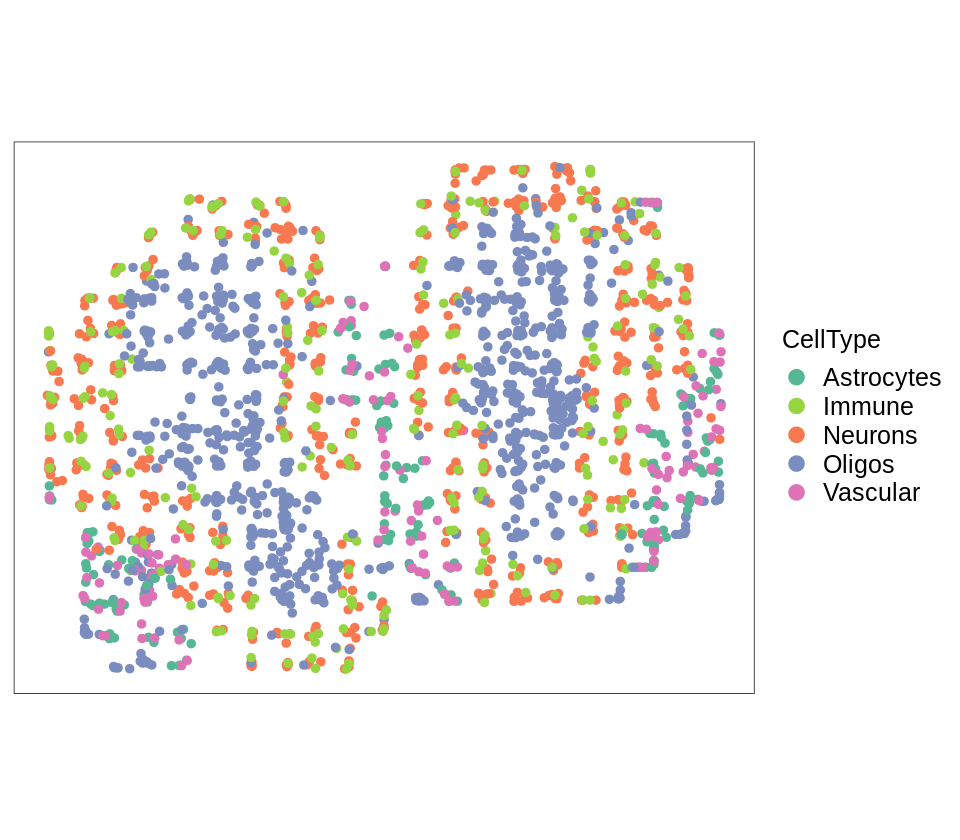

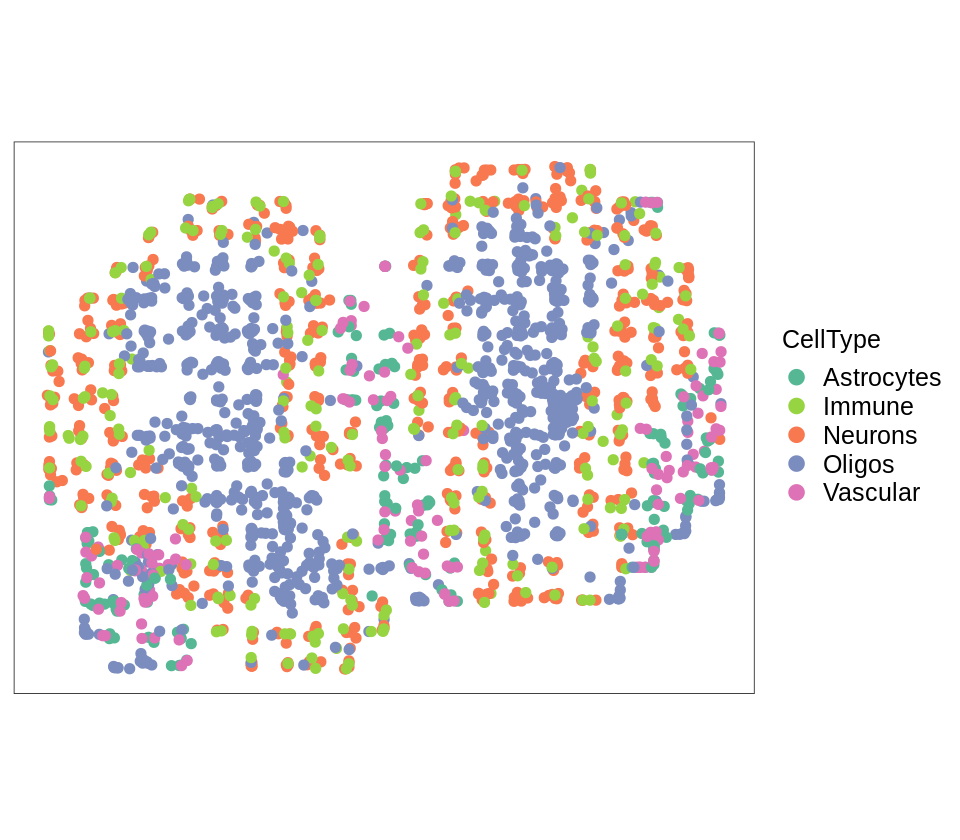

In [11]:
# size=2比较合适
options(repr.plot.width = 8, repr.plot.height = 7)
ggplot(sc_meta_coord,aes(pred_loc_x,pred_loc_y,color=cellType))+
    geom_point(size=2)+ #点的大小
   scale_color_manual(values = c(
                             "Astrocytes" = "#56B794",
                             "Ependymal" = "#FED225",
                             "Immune" = "#97D442",
                             "Neurons" = "#F87850",
                             "Oligos" = "#7B8CBF",
                             "Vascular" = "#DE72B6"))+
    theme_bw() +#去除背景
    theme(panel.grid.major=element_line(colour=NA), 
          panel.background = element_rect(fill = "transparent",colour = NA),
          plot.background = element_rect(fill = "transparent",colour = NA),
          ,panel.grid.minor=element_blank(),
          axis.text = element_blank(),
          axis.ticks = element_blank())+ coord_fixed()+
    labs(x=NULL,y=NULL,color= 'Cell Type')+
    theme(plot.title = element_text(hjust = 0.5)) + # 居中
   theme(legend.position='right',
        legend.text=element_text(size=15),
        legend.title=element_text(size=15))+
    guides(color = guide_legend(title="CellType",override.aes = list(size = 4)))

options(repr.plot.width = 8, repr.plot.height = 7)
ggplot(sc_meta_coord,aes(pred_loc_x,pred_loc_y,color=cellType))+
    geom_point(size=2.5)+ #点的大小
   scale_color_manual(values = c(
                             "Astrocytes" = "#56B794",
                             "Ependymal" = "#FED225",
                             "Immune" = "#97D442",
                             "Neurons" = "#F87850",
                             "Oligos" = "#7B8CBF",
                             "Vascular" = "#DE72B6"))+
    theme_bw() +#去除背景
    theme(panel.grid.major=element_line(colour=NA), 
          panel.background = element_rect(fill = "transparent",colour = NA),
          plot.background = element_rect(fill = "transparent",colour = NA),
          ,panel.grid.minor=element_blank(),
          axis.text = element_blank(),
          axis.ticks = element_blank())+ coord_fixed()+
    labs(x=NULL,y=NULL,color= 'Cell Type')+
    theme(plot.title = element_text(hjust = 0.5)) + # 居中
   theme(legend.position='right',
        legend.text=element_text(size=15),
        legend.title=element_text(size=15))+
    guides(color = guide_legend(title="CellType",override.aes = list(size = 4)))

Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


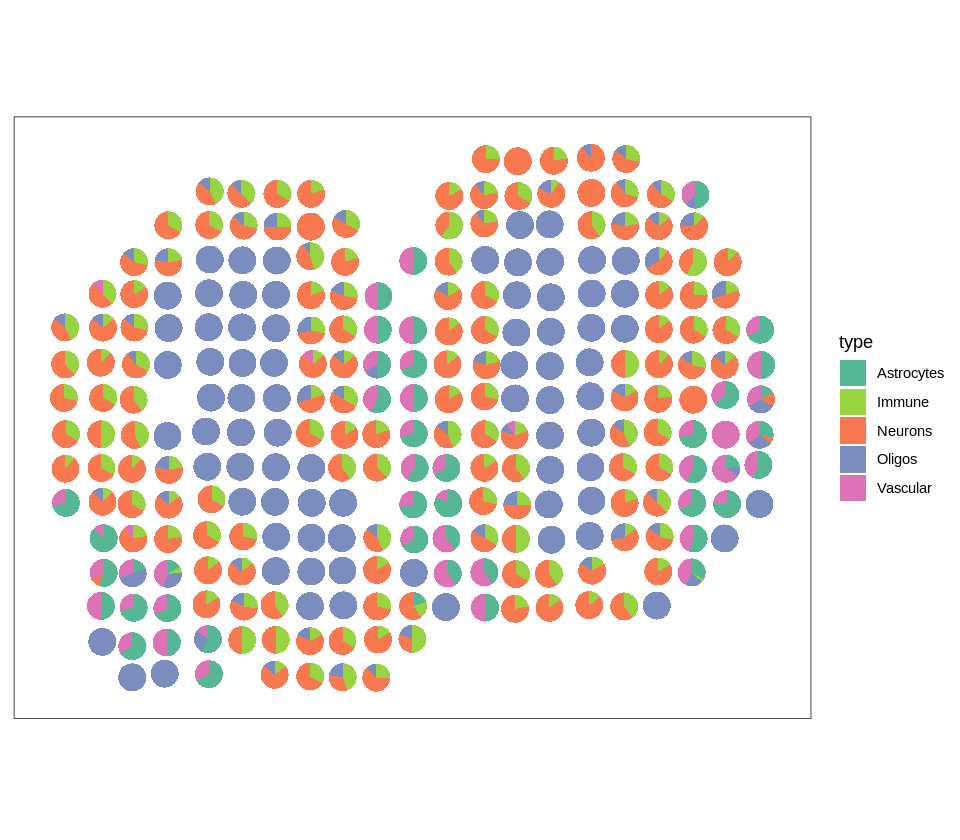

In [29]:
pie_plot <- cbind(cell_spot_map,cellType=sc_meta[as.character(cell_spot_map$Single_cell),'cellType'])
pie_spot <- as.data.frame.array(table(pie_plot$Spot,pie_plot$cellType))
pie_spot <- cbind(pie_spot,spatial_location[rownames(pie_spot),c('x','y')])
p <- ggplot() + geom_scatterpie(data=pie_spot,aes(x = x, y = y), 
                           cols=c(colnames(pie_spot)[1:5]),
                           color=NA)+ coord_equal() + theme_bw()+
  theme(panel.grid.major=element_blank(),panel.grid.minor=element_blank(),
          axis.text = element_blank(),
          axis.ticks = element_blank())+ coord_fixed()+
    labs(x=NULL,y=NULL,color= 'Cell Type')+
    theme(plot.title = element_text(hjust = 0.5)) + # 居中
    scale_fill_manual(values = c(
                             "Astrocytes" = "#56B794",
                             "Ependymal" = "#FED225",
                             "Immune" = "#97D442",
                             "Neurons" = "#F87850",
                             "Oligos" = "#7B8CBF",
                             "Vascular" = "#DE72B6"))+ guides(color = guide_legend(title="CellType"))
p